# 06 — τ selection (validation)


In [11]:
import os, math, json, shutil, time, pickle
from dataclasses import dataclass, field
from collections import defaultdict
from typing import List, Dict, Optional
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import numpy as np
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount("/content/drive")

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
torch.manual_seed(42); np.random.seed(42)

# === Publication-grade matplotlib style ===
import matplotlib as mpl
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["DejaVu Serif", "Times New Roman", "STIXGeneral"],
    "mathtext.fontset": "stix",
    "font.size": 9,
    "axes.labelsize": 9,
    "axes.titlesize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.fontsize": 8,
    "legend.frameon": False,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.linewidth": 1.4,
    "lines.markersize": 5,
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.04,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# Consistent palette across all 5 notebooks.
COLORS = {
    "softmax":  "#C0392B",   # red
    "sigmoid":  "#27AE60",   # green
    "neutral":  "#2C3E50",   # near-black
    "grey":     "#7F8C8D",
    "lightgrey":"#BDC3C7",
    "yellow":   "#F39C12",
    "blue":     "#2980B9",
    "purple":   "#8E44AD",
}

def style_for(spec):
    """Return (color, linestyle, marker, label) for a model spec tuple
    (name, display, use_rope, use_sigmoid, gated)."""
    _, display, use_rope, use_sigmoid, _ = spec
    color = COLORS["sigmoid"] if use_sigmoid else COLORS["softmax"]
    ls    = "-" if use_rope else "--"
    mk    = "o" if use_rope else "s"
    return color, ls, mk, display


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda


In [12]:
@dataclass
class Config:
    d_model: int = 768
    n_layer: int = 12
    n_head: int = 12
    d_ff: int = 3072
    block_size: int = 512
    vocab_size: int = 50257
    rope_base: float = 10000.0
    use_rope: bool = True       # toggled per spec
    use_sigmoid: bool = False   # toggled per spec

cfg_base = Config()

BASE       = "/content/drive/MyDrive/SigEvict"
DATA_DIR   = f"{BASE}/data"
MODEL_DIR  = f"{BASE}/models"
RESULT_DIR = f"{BASE}/results"
FIG_DIR    = f"{BASE}/figures"
TBL_DIR    = f"{BASE}/tables"
for d in [RESULT_DIR, FIG_DIR, TBL_DIR]: os.makedirs(d, exist_ok=True)

# 2 x 2 x 2 factorial: (attention) x (gate) x (position)
MODEL_SPECS = [
    # name                                  display          use_rope use_sigmoid gated
    ("gpt2_12L_dense_softmax",              "SM RoPE",         True,    False,   False),
    ("gpt2_12L_softmax_gated",              "SM+G RoPE",       True,    False,   True ),
    ("gpt2_12L_sigmoid_no_gate",            "Sig RoPE",        True,    True,    False),
    ("gpt2_12L_sigmoid_gated",              "Sig+G RoPE",      True,    True,    True ),
    ("gpt2_12L_dense_softmax_norope",       "SM NoPE",         False,   False,   False),
    ("gpt2_12L_softmax_gated_norope",       "SM+G NoPE",       False,   False,   True ),
    ("gpt2_12L_sigmoid_no_gate_norope",     "Sig NoPE",        False,   True,    False),
    ("gpt2_12L_sigmoid_gated_norope",       "Sig+G NoPE",      False,   True,    True ),
]
GATED_SPECS = [s for s in MODEL_SPECS if s[4]]
DENSE_SPECS = [s for s in MODEL_SPECS if not s[4]]
print(f"Registered {len(MODEL_SPECS)} models ({len(GATED_SPECS)} gated, {len(DENSE_SPECS)} dense)")

# Smoke toggle
SMOKE = False


Registered 8 models (4 gated, 4 dense)


## Model definitions (unified across all 8 specs)


In [13]:
class RMSNorm(nn.Module):
    def __init__(self, dim, eps=1e-6):
        super().__init__()
        self.eps, self.weight = eps, nn.Parameter(torch.ones(dim))
    def forward(self, x):
        return x / torch.sqrt(x.pow(2).mean(-1, keepdim=True) + self.eps) * self.weight

class RotaryEmbedding(nn.Module):
    def __init__(self, dim, max_len=2048, base=10000.0):
        super().__init__()
        self.register_buffer("inv_freq", 1.0 / (base ** (torch.arange(0, dim, 2).float() / dim)))
    def forward(self, seq_len, device):
        t = torch.arange(seq_len, device=device).float()
        freqs = torch.outer(t, self.inv_freq)
        emb = torch.cat([freqs, freqs], dim=-1)
        return emb.cos(), emb.sin()

def apply_rope(x, cos, sin, offset=0):
    d = x.shape[-1] // 2
    T = x.shape[2]
    x1, x2 = x[..., :d], x[..., d:]
    c = cos[offset:offset+T].unsqueeze(0).unsqueeze(0)
    s = sin[offset:offset+T].unsqueeze(0).unsqueeze(0)
    return torch.cat([x1*c[...,:d] - x2*s[...,:d], x1*s[...,:d] + x2*c[...,:d]], dim=-1)

class MLP(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.fc = nn.Linear(cfg.d_model, cfg.d_ff, bias=False)
        self.proj = nn.Linear(cfg.d_ff, cfg.d_model, bias=False)
    def forward(self, x): return self.proj(F.gelu(self.fc(x)))


In [14]:
class SoftmaxAttention(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.n_head, self.d_head = cfg.n_head, cfg.d_model // cfg.n_head
        self.scale = 1.0 / math.sqrt(self.d_head)
        self.c_attn = nn.Linear(cfg.d_model, 3 * cfg.d_model, bias=False)
        self.c_proj = nn.Linear(cfg.d_model, cfg.d_model, bias=False)
        self.q_norm, self.k_norm = RMSNorm(self.d_head), RMSNorm(self.d_head)
        if cfg.use_rope:
            self.rotary = RotaryEmbedding(self.d_head, cfg.block_size, cfg.rope_base)
        self.register_buffer("mask", torch.triu(torch.ones(cfg.block_size, cfg.block_size), diagonal=1).bool())

    def forward(self, x, kv_mask=None):
        B, T, C = x.shape
        q, k, v = self.c_attn(x).split(C, dim=-1)
        q = q.view(B, T, self.n_head, self.d_head).transpose(1, 2)
        k = k.view(B, T, self.n_head, self.d_head).transpose(1, 2)
        v = v.view(B, T, self.n_head, self.d_head).transpose(1, 2)
        q, k = self.q_norm(q), self.k_norm(k)
        if self.cfg.use_rope:
            cos, sin = self.rotary(T, x.device)
            q, k = apply_rope(q, cos, sin), apply_rope(k, cos, sin)
        att = (q @ k.transpose(-2, -1)) * self.scale
        att = att.masked_fill(self.mask[:T, :T], float("-inf"))
        if kv_mask is not None:
            m = kv_mask.unsqueeze(1)
            att = att + torch.log(kv_mask.squeeze(-1).unsqueeze(1).unsqueeze(2).clamp(min=1e-8))
            v = v * m
        att = F.softmax(att, dim=-1)
        return self.c_proj((att @ v).transpose(1, 2).contiguous().view(B, T, C))

    def forward_kv(self, x, kv_cache=None, kv_mask=None, start_pos=0):
        B, T, C = x.shape
        q, k, v = self.c_attn(x).split(C, dim=-1)
        q = q.view(B, T, self.n_head, self.d_head).transpose(1, 2)
        k = k.view(B, T, self.n_head, self.d_head).transpose(1, 2)
        v = v.view(B, T, self.n_head, self.d_head).transpose(1, 2)
        q, k = self.q_norm(q), self.k_norm(k)
        if self.cfg.use_rope:
            cos, sin = self.rotary(start_pos + T, x.device)
            q = apply_rope(q, cos, sin, offset=start_pos)
            k = apply_rope(k, cos, sin, offset=start_pos)
        if kv_cache is not None:
            k = torch.cat([kv_cache[0], k], dim=2)
            v = torch.cat([kv_cache[1], v], dim=2)
        T_full = k.size(2)
        att = (q @ k.transpose(-2, -1)) * self.scale
        causal = self.mask[start_pos:start_pos+T, :T_full]
        att = att.masked_fill(causal.unsqueeze(0).unsqueeze(0), float("-inf"))
        if kv_mask is not None:
            m = kv_mask.unsqueeze(1)
            att = att + torch.log(kv_mask.squeeze(-1).unsqueeze(1).unsqueeze(2).clamp(min=1e-8))
            v_att = v * m
        else:
            v_att = v
        att = F.softmax(att, dim=-1)
        y = (att @ v_att).transpose(1, 2).contiguous().view(B, T, C)
        return self.c_proj(y), (k, v)


class SigmoidAttention(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.n_head, self.d_head = cfg.n_head, cfg.d_model // cfg.n_head
        self.scale = 1.0 / math.sqrt(self.d_head)
        self.c_attn = nn.Linear(cfg.d_model, 3 * cfg.d_model, bias=False)
        self.c_proj = nn.Linear(cfg.d_model, cfg.d_model, bias=False)
        self.q_norm, self.k_norm = RMSNorm(self.d_head), RMSNorm(self.d_head)
        if cfg.use_rope:
            self.rotary = RotaryEmbedding(self.d_head, cfg.block_size, cfg.rope_base)
        self.register_buffer("mask", torch.triu(torch.ones(cfg.block_size, cfg.block_size), diagonal=1).bool())
        self.register_buffer("pos_bias", -torch.log(torch.arange(cfg.block_size, dtype=torch.float32) + 1))

    def forward(self, x, kv_mask=None):
        B, T, C = x.shape
        q, k, v = self.c_attn(x).split(C, dim=-1)
        q = q.view(B, T, self.n_head, self.d_head).transpose(1, 2)
        k = k.view(B, T, self.n_head, self.d_head).transpose(1, 2)
        v = v.view(B, T, self.n_head, self.d_head).transpose(1, 2)
        q, k = self.q_norm(q), self.k_norm(k)
        if self.cfg.use_rope:
            cos, sin = self.rotary(T, x.device)
            q, k = apply_rope(q, cos, sin), apply_rope(k, cos, sin)
        logits = (q @ k.transpose(-2, -1)) * self.scale + self.pos_bias[:T].view(1, 1, T, 1)
        if kv_mask is not None:
            m = kv_mask.unsqueeze(1)
            logits = logits + torch.log(kv_mask.squeeze(-1).unsqueeze(1).unsqueeze(2).clamp(min=1e-8))
            v = v * m
        attn = torch.sigmoid(logits.masked_fill(self.mask[:T, :T], -1e9)).masked_fill(self.mask[:T, :T], 0.0)
        return self.c_proj((attn @ v).transpose(1, 2).contiguous().view(B, T, C))

    def forward_kv(self, x, kv_cache=None, kv_mask=None, start_pos=0):
        B, T, C = x.shape
        q, k, v = self.c_attn(x).split(C, dim=-1)
        q = q.view(B, T, self.n_head, self.d_head).transpose(1, 2)
        k = k.view(B, T, self.n_head, self.d_head).transpose(1, 2)
        v = v.view(B, T, self.n_head, self.d_head).transpose(1, 2)
        q, k = self.q_norm(q), self.k_norm(k)
        if self.cfg.use_rope:
            cos, sin = self.rotary(start_pos + T, x.device)
            q = apply_rope(q, cos, sin, offset=start_pos)
            k = apply_rope(k, cos, sin, offset=start_pos)
        if kv_cache is not None:
            k = torch.cat([kv_cache[0], k], dim=2)
            v = torch.cat([kv_cache[1], v], dim=2)
        T_full = k.size(2)
        logits = (q @ k.transpose(-2, -1)) * self.scale
        if T == 1:
            logits = logits + (-math.log(start_pos + 1))
        else:
            logits = logits + self.pos_bias[:T].view(1, 1, T, 1)
        if kv_mask is not None:
            m = kv_mask.unsqueeze(1)
            logits = logits + torch.log(kv_mask.squeeze(-1).unsqueeze(1).unsqueeze(2).clamp(min=1e-8))
            v_att = v * m
        else:
            v_att = v
        causal = self.mask[start_pos:start_pos+T, :T_full]
        attn = torch.sigmoid(logits.masked_fill(causal.unsqueeze(0).unsqueeze(0), -1e9))
        attn = attn.masked_fill(causal.unsqueeze(0).unsqueeze(0), 0.0)
        y = (attn @ v_att).transpose(1, 2).contiguous().view(B, T, C)
        return self.c_proj(y), (k, v)


In [15]:
class Block(nn.Module):
    def __init__(self, cfg, attn_cls):
        super().__init__()
        self.ln1, self.attn = nn.LayerNorm(cfg.d_model), attn_cls(cfg)
        self.ln2, self.mlp = nn.LayerNorm(cfg.d_model), MLP(cfg)
    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        return x + self.mlp(self.ln2(x))
    def forward_kv(self, x, kv_cache=None, start_pos=0):
        attn_out, new_kv = self.attn.forward_kv(self.ln1(x), kv_cache=kv_cache, start_pos=start_pos)
        x = x + attn_out
        x = x + self.mlp(self.ln2(x))
        return x, new_kv

class GatedBlock(nn.Module):
    def __init__(self, cfg, layer_idx, attn_cls):
        super().__init__()
        self.ln1, self.attn = nn.LayerNorm(cfg.d_model), attn_cls(cfg)
        self.ln2, self.mlp = nn.LayerNorm(cfg.d_model), MLP(cfg)
        self.has_gate = layer_idx < cfg.n_layer - 1
        if self.has_gate:
            self.gate = nn.Linear(cfg.d_model, 1, bias=True)
    def forward(self, x, kv_mask=None):
        x = x + self.attn(self.ln1(x), kv_mask=kv_mask)
        x = x + self.mlp(self.ln2(x))
        g = torch.sigmoid(self.gate(x)) if self.has_gate else None
        return x, g
    def forward_kv(self, x, kv_cache=None, kv_mask=None, start_pos=0):
        attn_out, new_kv = self.attn.forward_kv(self.ln1(x), kv_cache=kv_cache,
                                                kv_mask=kv_mask, start_pos=start_pos)
        x = x + attn_out
        x = x + self.mlp(self.ln2(x))
        g = torch.sigmoid(self.gate(x)) if self.has_gate else None
        return x, new_kv, g


class GPT2Dense(nn.Module):
    def __init__(self, cfg, attn_cls):
        super().__init__()
        self.cfg = cfg
        self.wte = nn.Embedding(cfg.vocab_size, cfg.d_model)
        self.blocks = nn.ModuleList([Block(cfg, attn_cls) for _ in range(cfg.n_layer)])
        self.ln_f = nn.LayerNorm(cfg.d_model)
        self.head = nn.Linear(cfg.d_model, cfg.vocab_size, bias=False)
        self.wte.weight = self.head.weight

    def forward(self, idx, targets=None):
        x = self.wte(idx)
        for b in self.blocks: x = b(x)
        logits = self.head(self.ln_f(x))
        loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1)) if targets is not None else None
        return logits, loss

    def prefill(self, idx):
        B, T = idx.shape
        x = self.wte(idx)
        caches = []
        for block in self.blocks:
            x, kv = block.forward_kv(x, kv_cache=None, start_pos=0)
            caches.append(kv)
        logits = self.head(self.ln_f(x))
        return logits, caches

    def decode_step(self, tok, pos, caches):
        x = self.wte(tok)
        new_caches = []
        for l, block in enumerate(self.blocks):
            x, kv = block.forward_kv(x, kv_cache=caches[l], start_pos=pos)
            new_caches.append(kv)
        return self.head(self.ln_f(x)).squeeze(1), new_caches


class GPT2Gated(nn.Module):
    def __init__(self, cfg, attn_cls):
        super().__init__()
        self.cfg = cfg
        self.wte = nn.Embedding(cfg.vocab_size, cfg.d_model)
        self.blocks = nn.ModuleList([GatedBlock(cfg, i, attn_cls) for i in range(cfg.n_layer)])
        self.ln_f = nn.LayerNorm(cfg.d_model)
        self.head = nn.Linear(cfg.d_model, cfg.vocab_size, bias=False)
        self.wte.weight = self.head.weight

    def forward(self, idx, targets=None):
        x = self.wte(idx)
        kv_mask, gates = None, []
        for b in self.blocks:
            x, g = b(x, kv_mask=kv_mask)
            if g is not None: gates.append(g)
            kv_mask = g
        logits = self.head(self.ln_f(x))
        loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1)) if targets is not None else None
        budget = sum(g.mean() for g in gates) / len(gates) if gates else None
        return logits, loss, budget, gates

    def prefill(self, idx):
        B, T = idx.shape
        x = self.wte(idx)
        caches, cache_masks = [], []
        prev_mask = torch.ones(B, T, 1, device=idx.device)
        for block in self.blocks:
            x, kv, gate = block.forward_kv(x, kv_cache=None, kv_mask=prev_mask, start_pos=0)
            caches.append(kv); cache_masks.append(prev_mask)
            prev_mask = gate if gate is not None else torch.ones(B, T, 1, device=idx.device)
        return self.head(self.ln_f(x)), caches, cache_masks

    def decode_step(self, tok, pos, caches, cache_masks):
        B = tok.size(0)
        x = self.wte(tok)
        new_caches, new_cache_masks = [], []
        prev_gate_new = torch.ones(B, 1, 1, device=tok.device)
        for l, block in enumerate(self.blocks):
            kv_mask = torch.cat([cache_masks[l], prev_gate_new], dim=1)
            x, kv, gate = block.forward_kv(x, kv_cache=caches[l], kv_mask=kv_mask, start_pos=pos)
            new_caches.append(kv); new_cache_masks.append(kv_mask)
            prev_gate_new = gate if gate is not None else torch.ones(B, 1, 1, device=tok.device)
        return self.head(self.ln_f(x)).squeeze(1), new_caches, new_cache_masks


def build_model(spec):
    name, display, use_rope, use_sigmoid, gated = spec
    cfg = Config()
    cfg.use_rope = use_rope
    cfg.use_sigmoid = use_sigmoid
    attn_cls = SigmoidAttention if use_sigmoid else SoftmaxAttention
    model = GPT2Gated(cfg, attn_cls) if gated else GPT2Dense(cfg, attn_cls)
    return model, cfg

def load_model(spec, device=device):
    name = spec[0]
    ckpt = torch.load(f"{MODEL_DIR}/{name}.pt", map_location=device, weights_only=False)
    model, cfg = build_model(spec)
    missing, unexpected = model.load_state_dict(ckpt["model_state_dict"], strict=False)
    if missing or unexpected:
        print(f"  [warn] {name}: missing={len(missing)}, unexpected={len(unexpected)}")
    model = model.to(device).eval()
    best_tau = ckpt.get("best_tau", None)
    return model, cfg, best_tau


In [16]:
def physical_prune(caches, cache_masks, tau):
    """Drop KV entries with gate value < tau (per layer, independent)."""
    new_caches, new_masks = [], []
    for l in range(len(caches)):
        k, v = caches[l]; mask = cache_masks[l]
        keep = (mask.squeeze(-1) >= tau)
        keep_idx = keep[0].nonzero(as_tuple=True)[0]
        if len(keep_idx) == 0:
            keep_idx = torch.tensor([mask.size(1) - 1], device=mask.device)
        new_caches.append((k[:, :, keep_idx, :], v[:, :, keep_idx, :]))
        new_masks.append(mask[:, keep_idx, :])
    return new_caches, new_masks

def prune_new_token(caches, cache_masks, tau):
    new_caches, new_masks = [], []
    for l in range(len(caches)):
        k, v = caches[l]; mask = cache_masks[l]
        if (mask[:, -1:, :] < tau).all():
            new_caches.append((k[:, :, :-1, :], v[:, :, :-1, :]))
            new_masks.append(mask[:, :-1, :])
        else:
            new_caches.append((k, v)); new_masks.append(mask)
    return new_caches, new_masks

@torch.no_grad()
def eval_gated_at_tau(model, tokens, tau, n_seqs, prefill=384, decode=128):
    seq_losses, final_entries = [], []
    for si in range(n_seqs):
        s = si * (prefill + decode)
        if s + prefill + decode > len(tokens): break
        toks = tokens[s:s+prefill+decode].unsqueeze(0).to(device)
        prefix, suffix = toks[:, :prefill], toks[:, prefill:]
        with torch.amp.autocast("cuda", dtype=torch.bfloat16):
            pf_logits, caches, cmasks = model.prefill(prefix)
            if tau > 0:
                caches, cmasks = physical_prune(caches, cmasks, tau)
            seq = [F.cross_entropy(pf_logits[:, -1, :], suffix[:, 0]).item()]
            for t in range(decode - 1):
                logits, caches, cmasks = model.decode_step(
                    suffix[:, t:t+1], prefill + t, caches, cmasks)
                if tau > 0:
                    caches, cmasks = prune_new_token(caches, cmasks, tau)
                seq.append(F.cross_entropy(logits, suffix[:, t+1]).item())
        seq_losses.append(sum(seq) / len(seq))
        final_entries.append(sum(c[0].size(2) for c in caches))
    return seq_losses, sum(final_entries) / len(final_entries)

@torch.no_grad()
def eval_dense_protocol(model, tokens, n_seqs, prefill=384, decode=128):
    """Dense PPL on suffix tokens via single forward pass; matches gated protocol."""
    seq_losses = []
    for si in range(n_seqs):
        s = si * (prefill + decode)
        if s + prefill + decode > len(tokens): break
        toks = tokens[s:s+prefill+decode].unsqueeze(0).to(device)
        with torch.amp.autocast("cuda", dtype=torch.bfloat16):
            logits, _ = model(toks)
        lg = logits[:, prefill-1:prefill+decode-1, :].reshape(-1, logits.size(-1))
        tg = toks[:, prefill:prefill+decode].reshape(-1)
        per_tok = F.cross_entropy(lg, tg, reduction="none")
        seq_losses.append(per_tok.mean().item())
    return seq_losses


## Load val tokens


In [17]:
LOCAL = "/content/local_data"; os.makedirs(LOCAL, exist_ok=True)
src, dst = f"{DATA_DIR}/owt_val_100K.pt", f"{LOCAL}/owt_val_100K.pt"
if not os.path.exists(dst):
    print("Copying val tokens to local SSD...")
    shutil.copy(src, dst)
val_tokens = torch.load(dst, weights_only=True)
print(f"Val tokens: {len(val_tokens):,}")


Val tokens: 100,000


## Sanity check: prefill+decode protocol matches dense forward


In [18]:
@torch.no_grad()
def eval_dense_via_decode(model, tokens, n_seqs, prefill=384, decode=128):
    """Same protocol as eval_gated_at_tau but for dense model (no gate)."""
    seq_losses = []
    for si in range(n_seqs):
        s = si * (prefill + decode)
        if s + prefill + decode > len(tokens): break
        toks = tokens[s:s+prefill+decode].unsqueeze(0).to(device)
        prefix, suffix = toks[:, :prefill], toks[:, prefill:]
        with torch.amp.autocast("cuda", dtype=torch.bfloat16):
            pf_logits, caches = model.prefill(prefix)
            seq = [F.cross_entropy(pf_logits[:, -1, :], suffix[:, 0]).item()]
            for t in range(decode - 1):
                logits, caches = model.decode_step(suffix[:, t:t+1], prefill + t, caches)
                seq.append(F.cross_entropy(logits, suffix[:, t+1]).item())
        seq_losses.append(sum(seq) / len(seq))
    return seq_losses

# Run on the first dense model only (sanity check)
spec0 = DENSE_SPECS[0]
print(f"Sanity-checking protocol equivalence on {spec0[1]}...")
model0, cfg0, _ = load_model(spec0)
fwd = eval_dense_protocol(model0, val_tokens, n_seqs=20)
dec = eval_dense_via_decode(model0, val_tokens, n_seqs=20)
ppl_fwd = math.exp(sum(fwd)/len(fwd))
ppl_dec = math.exp(sum(dec)/len(dec))
print(f"  forward     PPL = {ppl_fwd:.4f}")
print(f"  prefill+dec PPL = {ppl_dec:.4f}")
print(f"  |Δ| = {abs(ppl_fwd-ppl_dec):.4f}  ({'OK' if abs(ppl_fwd-ppl_dec) < 0.05 else 'MISMATCH'})")
del model0; torch.cuda.empty_cache()


Sanity-checking protocol equivalence on SM RoPE...
  forward     PPL = 21.3142
  prefill+dec PPL = 21.2974
  |Δ| = 0.0168  (OK)


## Sweep configuration


In [19]:
if SMOKE:
    TAUS = [0.0, 0.1, 0.3, 0.5, 0.7, 0.9]
    N_SEQS = 20
else:
    TAUS = [0.0, 0.005, 0.01, 0.02, 0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
    N_SEQS = 100
print(f"TAUS ({len(TAUS)}): {TAUS}\nN_SEQS: {N_SEQS}")


TAUS (15): [0.0, 0.005, 0.01, 0.02, 0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
N_SEQS: 100


## Dense reference PPL (no eviction)


In [20]:
dense_ref = {}
for spec in DENSE_SPECS:
    name, display = spec[0], spec[1]
    print(f">>> dense ref: {display}")
    model, cfg, _ = load_model(spec)
    losses = eval_dense_protocol(model, val_tokens, N_SEQS)
    ppl = math.exp(min(np.mean(losses), 20.0))
    dense_ref[name] = {"display": display, "ppl": ppl}
    print(f"  PPL = {ppl:.3f}")
    del model; torch.cuda.empty_cache()


>>> dense ref: SM RoPE
  PPL = 18.976
>>> dense ref: Sig RoPE
  PPL = 19.636
>>> dense ref: SM NoPE
  PPL = 20.021
>>> dense ref: Sig NoPE
  PPL = 21.167


## Sweep τ for all 4 gated models


In [ ]:
sweep_data = {}   # name -> list[{tau, ppl, entries, compression, losses}]
for spec in GATED_SPECS:
    name, display = spec[0], spec[1]
    print(f"\n>>> {display}")
    model, cfg, _ = load_model(spec)

    rows, baseline_entries = [], None
    for tau in TAUS:
        t0 = time.time()
        losses, entries = eval_gated_at_tau(model, val_tokens, tau, N_SEQS)
        ppl = math.exp(min(np.mean(losses), 20.0))
        if baseline_entries is None: baseline_entries = entries
        comp = (1.0 - entries / baseline_entries) * 100.0
        rows.append({"tau": tau, "ppl": ppl, "entries": entries,
                     "compression": comp, "losses": losses})
        delta = ppl - rows[0]["ppl"]
        print(f"  τ={tau:.3f}  PPL={ppl:7.3f}  "
              f"comp={comp:5.1f}%  ΔPPL={delta:+6.3f}  ({time.time()-t0:.0f}s)")
    sweep_data[name] = rows
    del model; torch.cuda.empty_cache()



>>> SM+G RoPE
  τ=0.000  PPL= 19.617  comp=  0.0%  ΔPPL=+0.000  (67s)
  τ=0.005  PPL= 19.635  comp= 13.4%  ΔPPL=+0.018  (69s)
  τ=0.010  PPL= 19.693  comp= 18.7%  ΔPPL=+0.077  (69s)
  τ=0.020  PPL= 19.957  comp= 25.3%  ΔPPL=+0.341  (70s)
  τ=0.050  PPL= 21.028  comp= 32.9%  ΔPPL=+1.412  (69s)
  τ=0.100  PPL= 23.129  comp= 40.7%  ΔPPL=+3.513  (69s)
  τ=0.150  PPL= 29.710  comp= 48.4%  ΔPPL=+10.093  (69s)
  τ=0.200  PPL=117.848  comp= 56.6%  ΔPPL=+98.231  (69s)
  τ=0.300  PPL=504.078  comp= 70.0%  ΔPPL=+484.462  (69s)
  τ=0.400  PPL=736.586  comp= 77.9%  ΔPPL=+716.969  (69s)
  τ=0.500  PPL=856.366  comp= 82.7%  ΔPPL=+836.749  (69s)
  τ=0.600  PPL=1125.443  comp= 86.7%  ΔPPL=+1105.826  (69s)
  τ=0.700  PPL=1368.692  comp= 88.5%  ΔPPL=+1349.075  (69s)
  τ=0.800  PPL=1557.720  comp= 90.0%  ΔPPL=+1538.103  (69s)
  τ=0.900  PPL=1913.991  comp= 90.8%  ΔPPL=+1894.374  (69s)

>>> Sig+G RoPE
  τ=0.000  PPL= 19.480  comp=  0.0%  ΔPPL=+0.000  (67s)
  τ=0.005  PPL= 19.480  comp= 14.2%  ΔPPL=-0.000 

## Pick best τ per model (max compression with ΔPPL < 0.1)


In [ ]:
DELTA_BUDGET = 0.1
best_taus = {}
print(f"{'Model':<14} {'best_τ':>8} {'PPL':>8} {'ΔPPL':>8} {'comp%':>8}")
print("-" * 52)
for name, rows in sweep_data.items():
    base = rows[0]["ppl"]
    cands = [r for r in rows if r["ppl"] - base < DELTA_BUDGET]
    best  = max(cands, key=lambda r: r["compression"])
    best_taus[name] = best["tau"]
    disp = [s[1] for s in MODEL_SPECS if s[0]==name][0]
    print(f"{disp:<14} {best['tau']:>8.3f} {best['ppl']:>8.3f} "
          f"{best['ppl']-base:>+8.3f} {best['compression']:>7.1f}%")


Model            best_τ      PPL     ΔPPL    comp%
----------------------------------------------------
SM+G RoPE         0.010   19.693   +0.077    18.7%
Sig+G RoPE        0.050   19.479   -0.001    18.8%
SM+G NoPE         0.010   20.259   +0.016     9.7%
Sig+G NoPE        0.050   21.155   +0.033    31.5%


## Persist back to checkpoints


In [ ]:
def _strip(rows):
    return [{k:v for k,v in r.items() if k != "losses"} for r in rows]

for name, tau in best_taus.items():
    p = f"{MODEL_DIR}/{name}.pt"
    ck = torch.load(p, map_location="cpu", weights_only=False)
    ck["best_tau"] = tau
    ck["sweep_results_val"] = _strip(sweep_data[name])
    torch.save(ck, p)
    print(f"  → wrote best_tau={tau:.3f} to {name}.pt")

with open(f"{RESULT_DIR}/best_taus.json", "w") as f:
    json.dump({
        "best_taus": best_taus,
        "dense_ref": dense_ref,
        "sweep_data": {n: _strip(r) for n, r in sweep_data.items()},
        "config": {"taus": TAUS, "n_seqs": N_SEQS, "prefill": 384, "decode": 128,
                   "delta_budget": DELTA_BUDGET, "split": "val"},
    }, f, indent=2)
print(f"\nSaved {RESULT_DIR}/best_taus.json")


  → wrote best_tau=0.010 to gpt2_12L_softmax_gated.pt
  → wrote best_tau=0.050 to gpt2_12L_sigmoid_gated.pt
  → wrote best_tau=0.010 to gpt2_12L_softmax_gated_norope.pt
  → wrote best_tau=0.050 to gpt2_12L_sigmoid_gated_norope.pt

Saved /content/drive/MyDrive/SigEvict/results/best_taus.json


## Sup. Fig. 1: val Pareto curves (compression vs PPL)


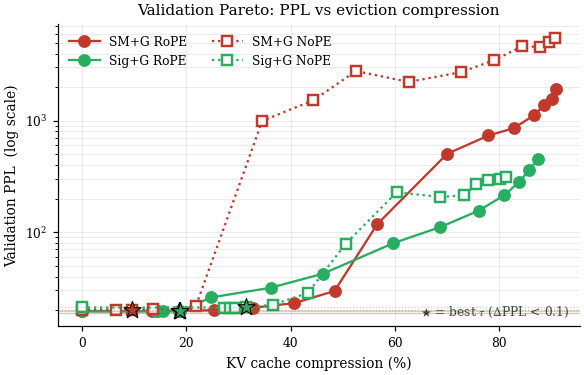

Saved /content/drive/MyDrive/SigEvict/figures/sup_val_pareto.{pdf,png}


In [ ]:
# Visual encoding for line plots:
#   color  = attention type (red=softmax, green=sigmoid)
#   marker shape + line style + fill jointly encode PE
#     RoPE: solid line, filled circle
#     NoPE: dotted line, hollow square
def line_style(spec):
    """spec = (name, display, use_rope, use_sigmoid, gated)"""
    _, display, use_rope, use_sigmoid, _ = spec
    color = COLORS["sigmoid"] if use_sigmoid else COLORS["softmax"]
    if use_rope:
        return dict(color=color, ls="-",  marker="o", mfc=color, mec=color,
                    mew=1.4, ms=7, lw=1.5, label=display)
    else:
        return dict(color=color, ls=":",  marker="s", mfc="white", mec=color,
                    mew=1.6, ms=7, lw=1.5, label=display)

fig, ax = plt.subplots(figsize=(5.5, 3.6))

# Gated curves — Pareto front per model, marker at every τ
for spec in GATED_SPECS:
    name = spec[0]
    rows = sorted(sweep_data[name], key=lambda r: r["compression"])
    comps = [r["compression"] for r in rows]
    ppls  = [r["ppl"]         for r in rows]
    ax.plot(comps, ppls, **line_style(spec))
    # ★ at the validation-selected operating point
    btau = best_taus[name]
    bp = next(r for r in rows if r["tau"] == btau)
    color = COLORS["sigmoid"] if spec[3] else COLORS["softmax"]
    ax.scatter([bp["compression"]], [bp["ppl"]], s=140, marker="*",
               color=color, edgecolors="black", linewidths=0.7, zorder=5)

# Dense reference horizontal lines (one per dense backbone, faint)
for name, d in dense_ref.items():
    spec = next(s for s in DENSE_SPECS if s[0] == name)
    color = COLORS["sigmoid"] if spec[3] else COLORS["softmax"]
    ls = "-" if spec[2] else ":"
    ax.axhline(d["ppl"], color=color, ls=ls, alpha=0.35, lw=0.8)

ax.set_yscale("log")
ax.set_xlabel("KV cache compression (%)")
ax.set_ylabel("Validation PPL  (log scale)")
ax.set_title("Validation Pareto: PPL vs eviction compression")
ax.grid(alpha=0.3, which="both", lw=0.5)
ax.legend(loc="upper left", ncol=2, fontsize=8, handlelength=2.5, framealpha=0.85)

ax.text(0.98, 0.02, r"$\bigstar$ = best $\tau$ ($\Delta$PPL < 0.1)",
        transform=ax.transAxes, ha="right", va="bottom",
        fontsize=8, color="black", alpha=0.7)

plt.tight_layout()
for ext in ["pdf", "png"]:
    plt.savefig(f"{FIG_DIR}/sup_val_pareto.{ext}", dpi=300)
plt.show()
print(f"Saved {FIG_DIR}/sup_val_pareto.{{pdf,png}}")


## Per-τ detail table (for appendix)


In [ ]:
hdr = f"{'τ':>6} |"
for spec in GATED_SPECS:
    hdr += f" {spec[1][:12]:>12} |"
print(hdr)
print("-" * len(hdr))
for i, tau in enumerate(TAUS):
    row = f"{tau:>6.3f} |"
    for spec in GATED_SPECS:
        r = sweep_data[spec[0]][i]
        row += f" {r['ppl']:>5.2f}/{r['compression']:>4.1f}% |"
    print(row)


     τ |    SM+G RoPE |   Sig+G RoPE |    SM+G NoPE |   Sig+G NoPE |
--------------------------------------------------------------------
 0.000 | 19.62/ 0.0% | 19.48/ 0.0% | 20.24/ 0.0% | 21.12/ 0.0% |
 0.005 | 19.63/13.4% | 19.48/14.2% | 20.24/ 6.5% | 21.11/27.3% |
 0.010 | 19.69/18.7% | 19.48/14.6% | 20.26/ 9.7% | 21.11/28.4% |
 0.020 | 19.96/25.3% | 19.48/15.6% | 20.36/13.7% | 21.11/29.3% |
 0.050 | 21.03/32.9% | 19.48/18.8% | 21.57/21.8% | 21.16/31.5% |
 0.100 | 23.13/40.7% | 26.02/24.8% | 995.48/34.6% | 22.35/36.6% |
 0.150 | 29.71/48.4% | 31.73/36.2% | 1524.68/44.4% | 28.46/43.3% |
 0.200 | 117.85/56.6% | 42.51/46.2% | 2786.99/52.5% | 78.84/50.6% |
 0.300 | 504.08/70.0% | 79.86/59.7% | 2224.26/62.6% | 228.40/60.3% |
 0.400 | 736.59/77.9% | 111.25/68.7% | 2727.09/72.7% | 206.53/68.7% |
 0.500 | 856.37/82.7% | 156.11/76.0% | 3489.68/79.0% | 214.38/73.2% |
 0.600 | 1125.44/86.7% | 215.09/81.0% | 4659.00/84.4% | 270.07/75.6% |
 0.700 | 1368.69/88.5% | 280.60/83.7% | 4585.06/87.7% | 